# Exploración Inicial - Commodities y Predictores

**Objetivo:** Validar descarga de datos y explorar estructura básica

Este notebook usa los módulos de `src/` para:
- Cargar datos de commodities y predictores
- Verificar cobertura temporal
- Analizar valores faltantes
- Visualizar series temporales

In [2]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Importar módulos del proyecto
from src.data import download_commodities, download_predictors, process
from src.config import INTERIM_COMMODITIES_DIR, INTERIM_PREDICTORS_DIR, PROCESSED_DIR, FIGURES_DIR
from src.visualization.estilo_graficos import configurar_estilo_grafico, formatear_ejes, forzar_y_cero

# Configurar estilo visual institucional
COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")
%matplotlib inline

pd.options.display.max_columns = 50
pd.options.display.max_rows = 100

ModuleNotFoundError: No module named 'src'

## 1. Cargar Datos

Cargamos commodities y predictores desde `data/interim/`

In [ ]:
# Cargar commodities
df_commodities = process.load_all_commodities()
df_commodities.head()

2025-10-27 12:57:20 - src.config - INFO - Cargando commodities desde interim...
2025-10-27 12:57:20 - src.config - INFO -   ✓ brent_crude.csv: 4,540 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ brent_crude.csv: 4,540 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ cocoa.csv: 6,475 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ cocoa.csv: 6,475 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ coffee.csv: 6,473 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ coffee.csv: 6,473 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ copper.csv: 6,318 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ corn.csv: 6,325 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ copper.csv: 6,318 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ corn.csv: 6,325 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ cotton.csv: 6,475 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ crude_oil.csv: 6,322 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ cotton.csv: 6,475 obs
2025-10-27 12:57:20 - src.con

,date,close,high,low,open,volume,commodity,ticker
0,2007-07-30,75.739998,76.529999,75.440002,75.849998,2575,Brent_Crude,BZ=F
1,2007-07-31,77.050003,77.169998,75.669998,75.699997,3513,Brent_Crude,BZ=F
2,2007-08-01,75.349998,77.059998,74.860001,77.000000,3930,Brent_Crude,BZ=F
3,2007-08-02,75.760002,76.209999,74.269997,75.220001,6180,Brent_Crude,BZ=F
4,2007-08-03,74.750000,76.000000,74.529999,75.389999,4387,Brent_Crude,BZ=F


In [ ]:
# Cargar predictores
df_predictors = process.load_all_predictors()
df_predictors.head()

2025-10-27 12:57:20 - src.config - INFO - 
Cargando predictores desde interim...
2025-10-27 12:57:20 - src.config - INFO -   ✓ dxy.csv: 6,523 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ energy_index.csv: 6,494 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ dxy.csv: 6,523 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ energy_index.csv: 6,494 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ materials_index.csv: 0 obs
2025-10-27 12:57:21 - src.config - INFO -   ✓ sp500.csv: 6,494 obs
2025-10-27 12:57:20 - src.config - INFO -   ✓ materials_index.csv: 0 obs
2025-10-27 12:57:21 - src.config - INFO -   ✓ sp500.csv: 6,494 obs
2025-10-27 12:57:21 - src.config - INFO -   ✓ treasury_10y.csv: 6,488 obs
2025-10-27 12:57:21 - src.config - INFO -   ✓ vix.csv: 6,494 obs
2025-10-27 12:57:21 - src.config - INFO -   ✓ treasury_10y.csv: 6,488 obs
2025-10-27 12:57:21 - src.config - INFO -   ✓ vix.csv: 6,494 obs
2025-10-27 12:57:21 - src.config - INFO - Total predictores: 32,493 observaciones
2

,date,close,high,low,open,volume,predictor,adj close
0,2000-01-03,100.220001,101.830002,100.190002,101.669998,0,DXY,NaN
1,2000-01-04,100.410004,100.860001,100.010002,100.550003,0,DXY,NaN
2,2000-01-05,100.379997,100.470001,99.709999,100.419998,0,DXY,NaN
3,2000-01-06,100.650002,100.809998,99.809998,100.309998,0,DXY,NaN
4,2000-01-07,100.800003,100.930000,100.440002,100.489998,0,DXY,NaN


## 2. Análisis de Cobertura Temporal

In [ ]:
# Cobertura por commodity
cobertura_commodities = df_commodities.groupby('commodity').agg({
    'date': ['min', 'max', 'count']
}).round(0)

cobertura_commodities.columns = ['Inicio', 'Fin', 'Observaciones']
cobertura_commodities = cobertura_commodities.sort_values('Inicio')
print("\n📊 Cobertura de Commodities:")
cobertura_commodities


📊 Cobertura de Commodities:


,Inicio,Fin,Observaciones
commodity,,,
Cocoa,2000-01-03,2025-10-27,6475
Coffee,2000-01-03,2025-10-27,6473
Cotton,2000-01-03,2025-10-27,6475
Oat,2000-01-03,2025-10-27,6328
Palladium,2000-01-04,2025-10-27,6036
Platinum,2000-01-04,2025-10-27,5797
Sugar,2000-03-01,2025-10-27,6436
Wheat,2000-07-17,2025-10-27,6337
Corn,2000-07-17,2025-10-27,6325


In [ ]:
# Cobertura por predictor
cobertura_predictores = df_predictors.groupby('predictor').agg({
    'date': ['min', 'max', 'count']
}).round(0)

cobertura_predictores.columns = ['Inicio', 'Fin', 'Observaciones']
cobertura_predictores = cobertura_predictores.sort_values('Inicio')
print("\n📊 Cobertura de Predictores:")
cobertura_predictores


📊 Cobertura de Predictores:


,Inicio,Fin,Observaciones
predictor,,,
DXY,2000-01-03,2025-10-27,6523
Energy_Index,2000-01-03,2025-10-27,6494
SP500,2000-01-03,2025-10-27,6494
Treasury_10Y,2000-01-03,2025-10-27,6488
VIX,2000-01-03,2025-10-27,6494


## 3. Valores Faltantes

In [ ]:
# Missing values en commodities
missing_commodities = df_commodities[['commodity', 'close']].groupby('commodity').apply(
    lambda x: x['close'].isnull().sum()
).sort_values(ascending=False)

print("\n🔍 Missing Values en Close - Commodities:")
print(missing_commodities[missing_commodities > 0])

if missing_commodities.sum() == 0:
    print("✓ No hay valores faltantes en commodities")


🔍 Missing Values en Close - Commodities:
Series([], dtype: int64)
✓ No hay valores faltantes en commodities


In [ ]:
# Missing values en predictores
missing_predictores = df_predictors[['predictor', 'close']].groupby('predictor').apply(
    lambda x: x['close'].isnull().sum()
).sort_values(ascending=False)

print("\n🔍 Missing Values en Close - Predictores:")
print(missing_predictores[missing_predictores > 0])

if missing_predictores.sum() == 0:
    print("✓ No hay valores faltantes en predictores")


🔍 Missing Values en Close - Predictores:
Series([], dtype: int64)
✓ No hay valores faltantes en predictores


## 4. Visualización de Series Temporales

### 4.1 Commodities Seleccionados

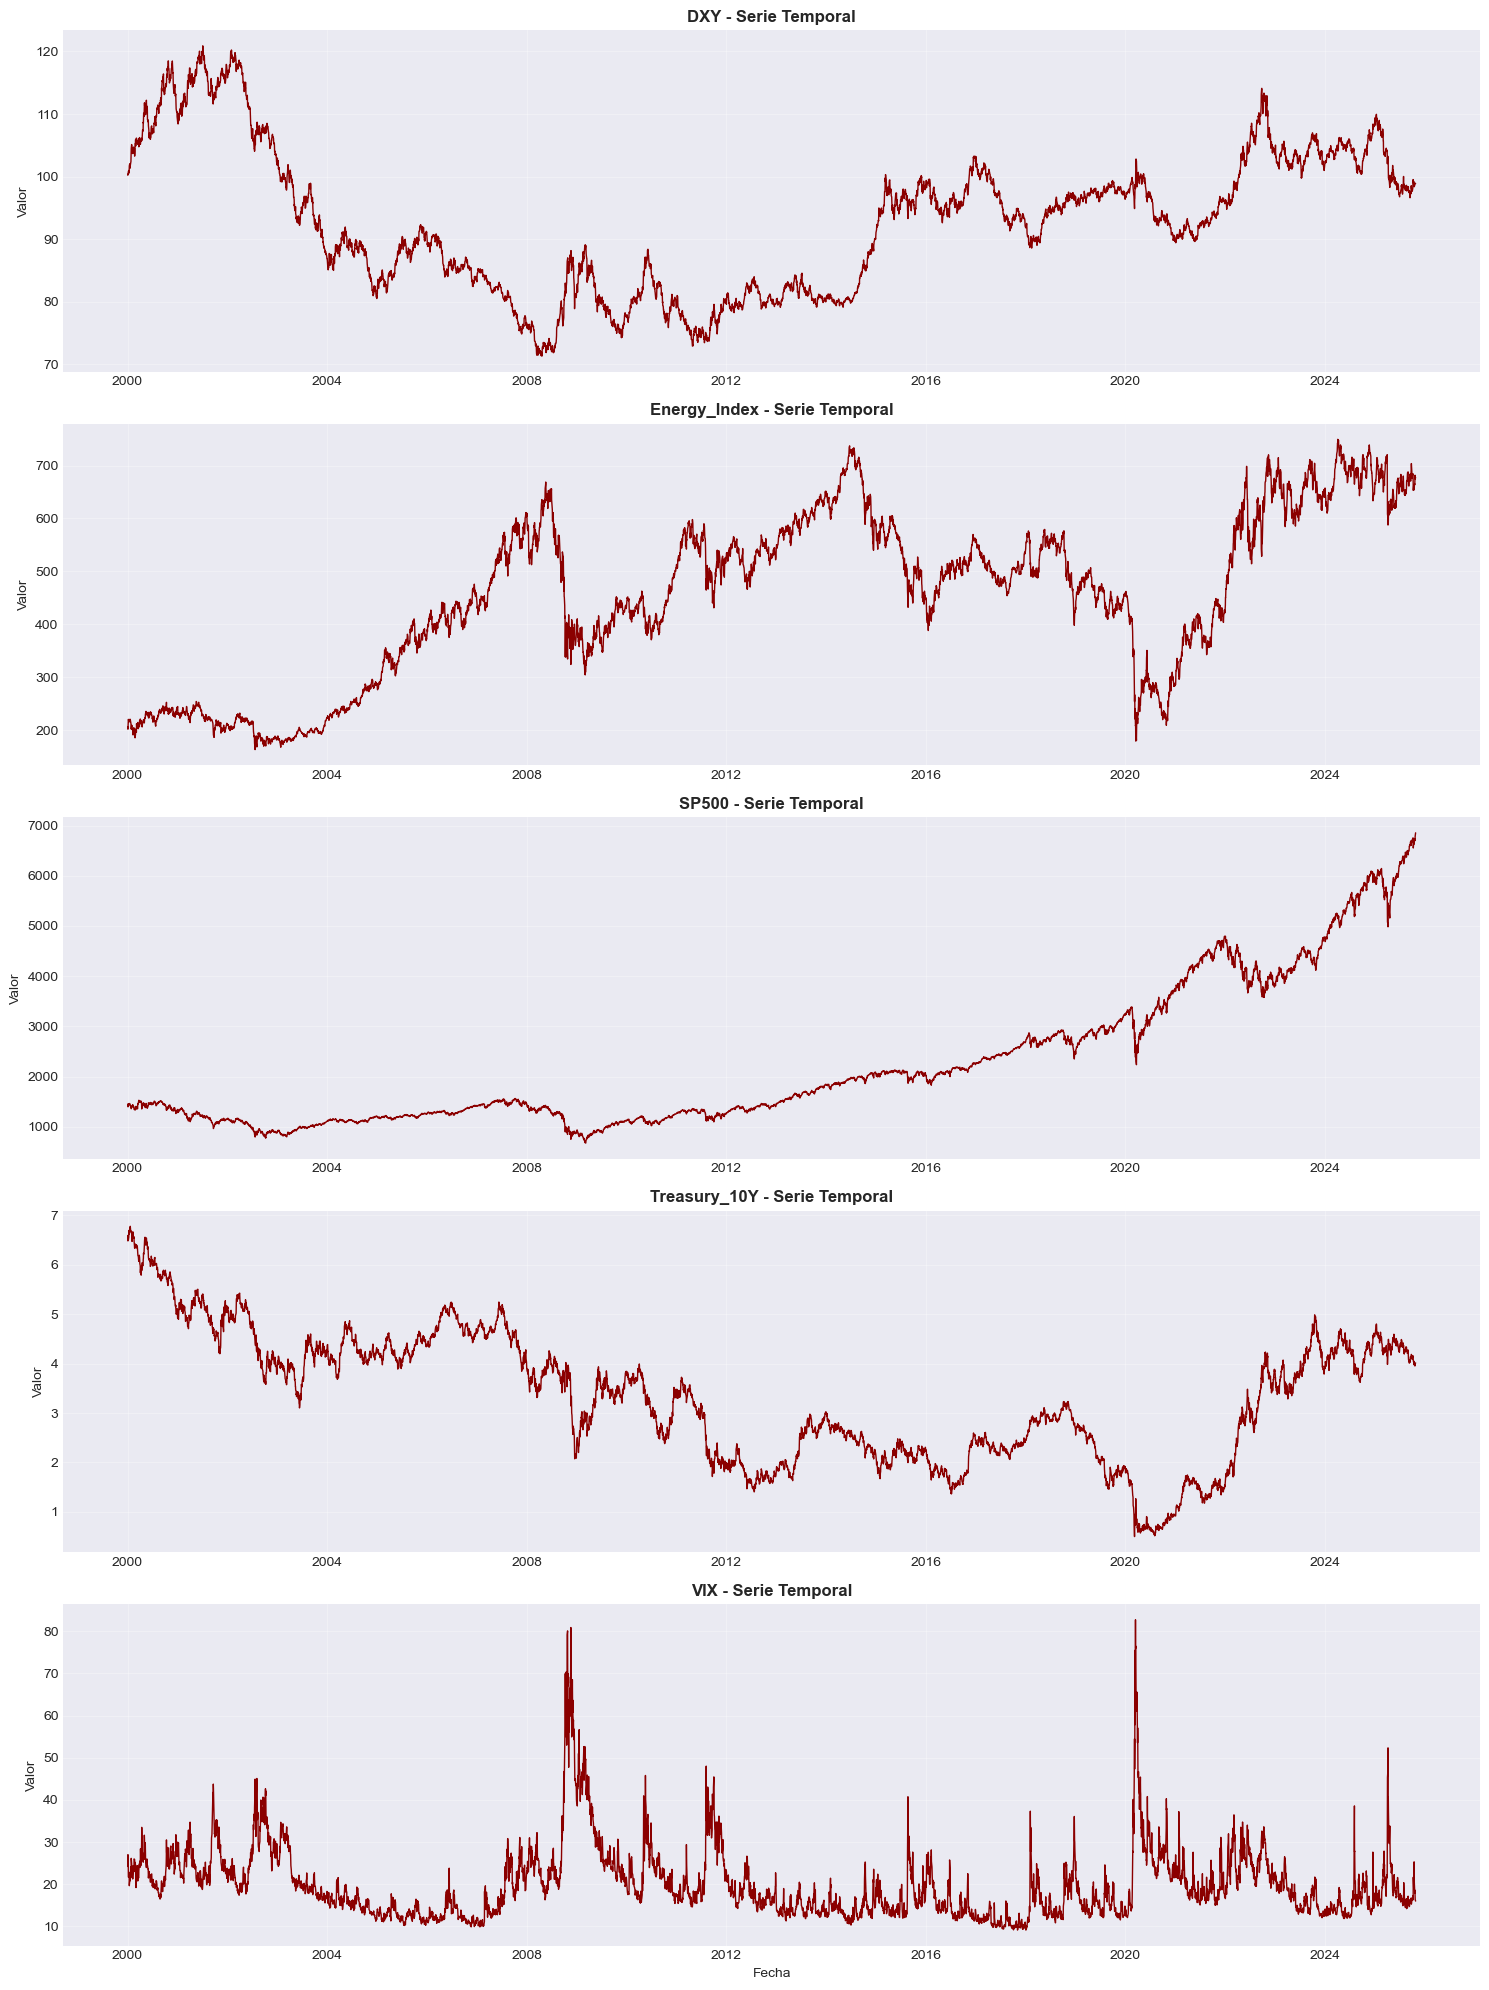

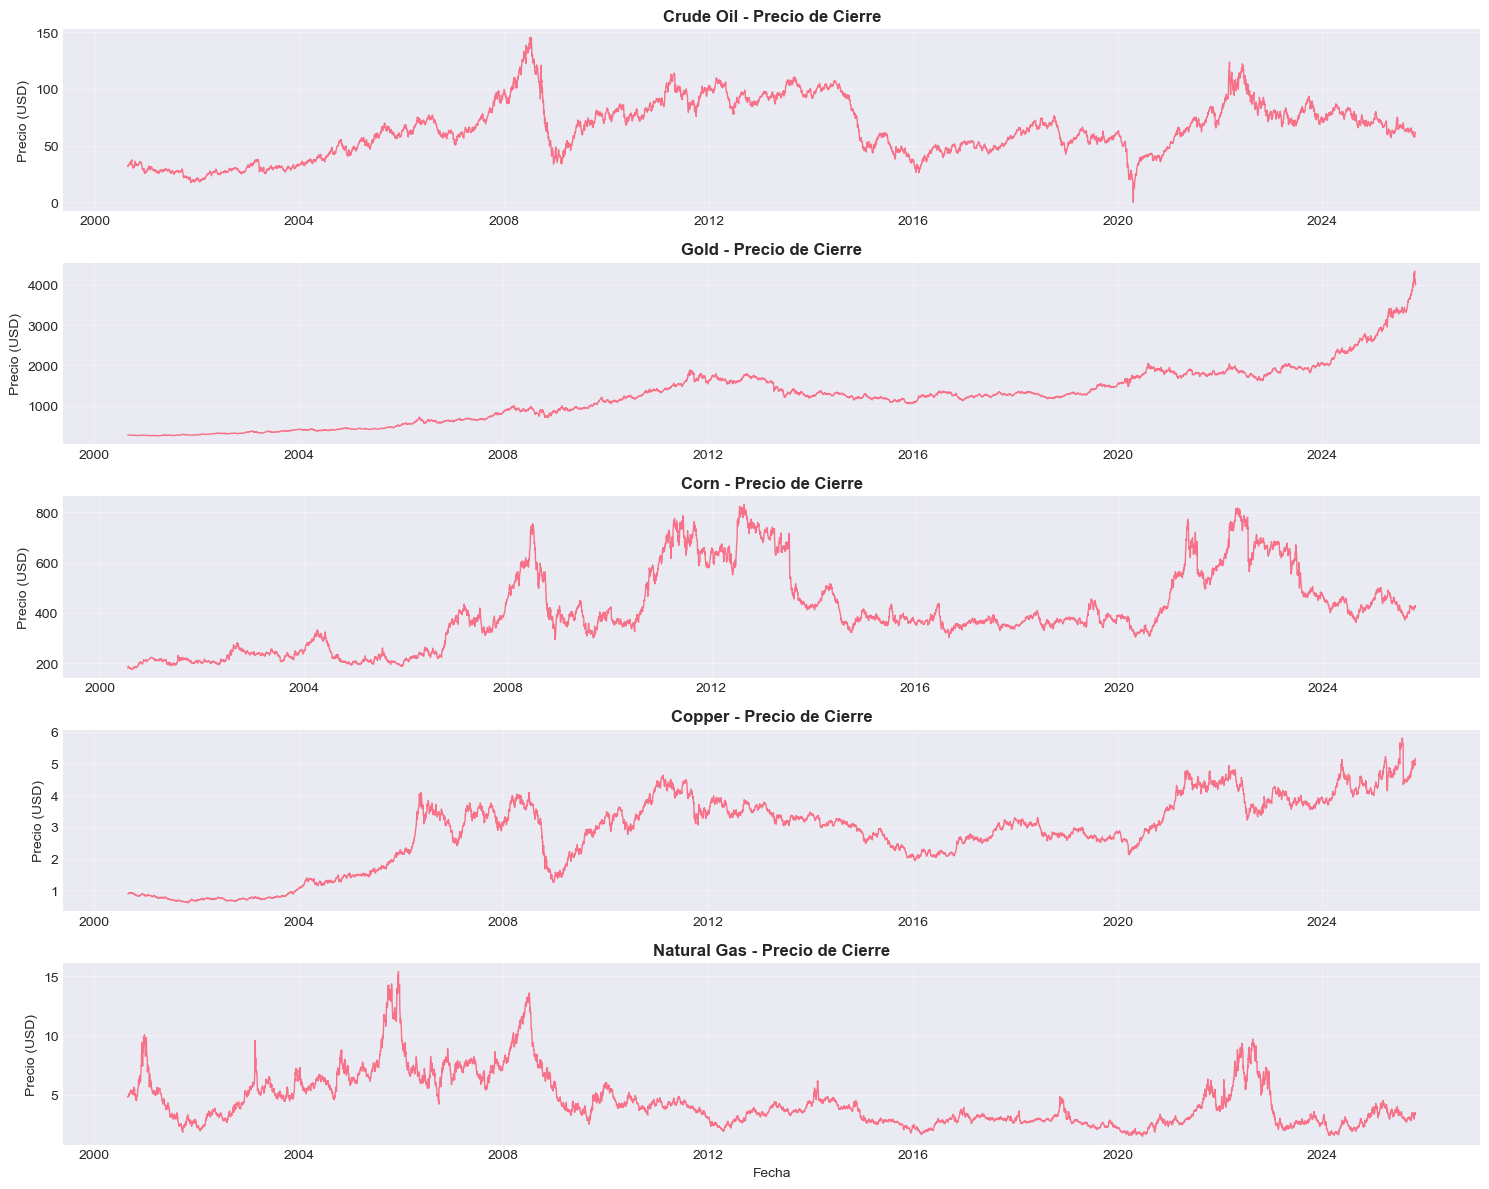

In [ ]:
# Seleccionar commodities representativos
commodities_viz = ['Crude_Oil', 'Gold', 'Corn', 'Copper', 'Natural_Gas']

fig, axes = plt.subplots(len(commodities_viz), 1, figsize=(15, 12))

for i, commodity in enumerate(commodities_viz):
    df_temp = df_commodities[df_commodities['commodity'] == commodity].copy()
    df_temp = df_temp.sort_values('date')
    
    axes[i].plot(df_temp['date'], df_temp['close'], linewidth=2, color=COLORES['azul_uba'])
    axes[i].set_title(f'{commodity.replace("_", " ")} - Precio de Cierre', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Precio (USD)')
    formatear_ejes(axes[i], y_as='numero')

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'exploracion_commodities_series.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 Predictores

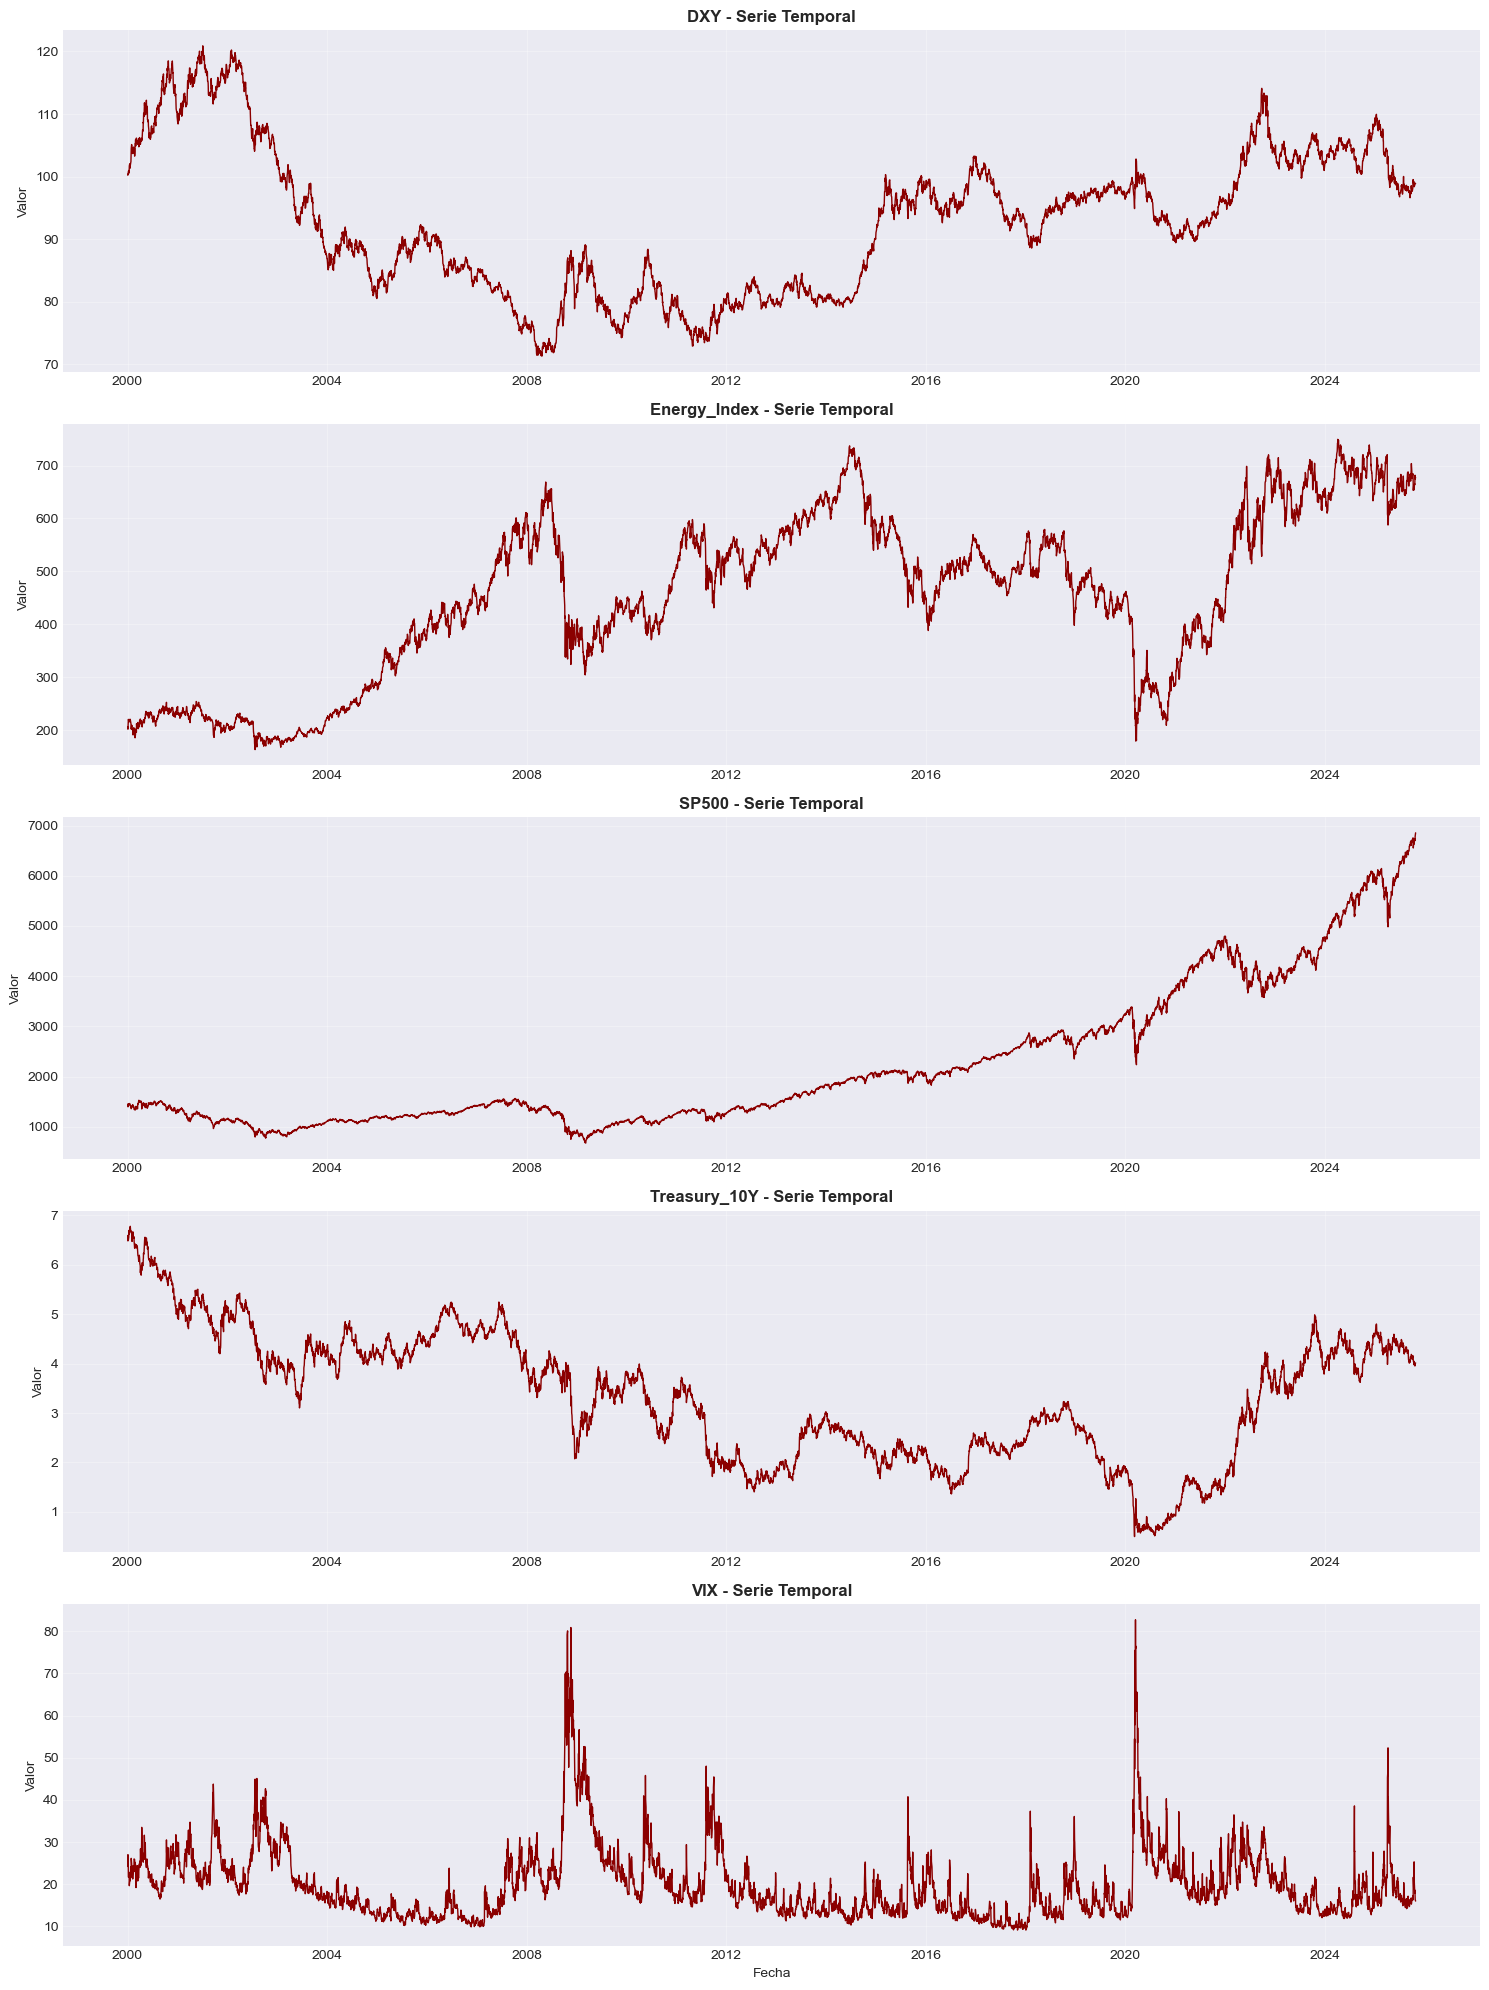

In [ ]:
# Visualizar todos los predictores disponibles
predictores_disponibles = df_predictors['predictor'].unique()

fig, axes = plt.subplots(len(predictores_disponibles), 1, figsize=(15, 4*len(predictores_disponibles)))

if len(predictores_disponibles) == 1:
    axes = [axes]

for i, predictor in enumerate(predictores_disponibles):
    df_temp = df_predictors[df_predictors['predictor'] == predictor].copy()
    df_temp = df_temp.sort_values('date')
    
    axes[i].plot(df_temp['date'], df_temp['close'], linewidth=2, color=COLORES['bordo'])
    axes[i].set_title(f'{predictor} - Serie Temporal', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Valor')
    formatear_ejes(axes[i], y_as='numero')

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'exploracion_predictores_series.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Estadísticas Descriptivas

In [ ]:
# Estadísticas por commodity
stats_commodities = df_commodities.groupby('commodity')['close'].describe().round(2)
stats_commodities = stats_commodities.sort_values('mean', ascending=False)
print("\n📊 Estadísticas Descriptivas - Commodities:")
stats_commodities

In [ ]:
# Estadísticas por predictor
stats_predictores = df_predictors.groupby('predictor')['close'].describe().round(2)
print("\n📊 Estadísticas Descriptivas - Predictores:")
stats_predictores

## 6. Distribuciones de Precios

In [ ]:
# Distribuciones de commodities seleccionados
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colores_ciclo = [COLORES['azul_uba'], COLORES['bordo'], COLORES['verde_eco'], 
                 COLORES['azul_medio'], COLORES['naranja']]

for i, commodity in enumerate(commodities_viz):
    df_temp = df_commodities[df_commodities['commodity'] == commodity]['close'].dropna()
    
    axes[i].hist(df_temp, bins=50, edgecolor='white', alpha=0.8, color=colores_ciclo[i])
    axes[i].set_title(commodity.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Precio')
    axes[i].set_ylabel('Frecuencia')
    formatear_ejes(axes[i], y_as='numero')

# Eliminar subplot vacío si hay menos de 6 commodities
if len(commodities_viz) < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'exploracion_distribuciones.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Conclusiones Preliminares

**Resumen de exploración inicial:**

1. **Cobertura temporal:** Verificar que todas las series tienen datos desde la fecha esperada
2. **Calidad de datos:** Identificar series con valores faltantes que requieren imputación
3. **Volatilidad:** Observar commodities con alta variabilidad (e.g., energía)
4. **Tendencias:** Detectar patrones temporales y ciclos

**Próximos pasos:**
- Procesar datos en formato wide para análisis multivariado
- Calcular retornos y volatilidad
- Analizar correlaciones entre commodities y predictores